In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [5]:
# Carregando os dados reais do Kaggle
df = pd.read_csv('../data/gym_members_dataset.csv')

# Visualizando se deu certo
print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

# ver se estao em minusculo 
df.columns = df.columns.str.lower()

O dataset tem 150 linhas e 15 colunas.


,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


Visualisar os dados mais por dentro para depois realizar um projeto de machine learinings


In [6]:
df.isnull().sum()

member_id                    0
name                        23
age                         13
gender                       0
address                      0
phone_number                 0
membership_type              0
join_date                    9
last_visit_date              0
favorite_exercise            0
avg_workout_duration_min     0
avg_calories_burned         11
total_weight_lifted_kg       8
visits_per_month            12
churn                        0
dtype: int64

In [ ]:
df.duplicated().sum()


np.int64(0)

In [8]:
#nao existe linhas duplicadas mas existem nulas vamos ver oque podemos fazer 
# 1. Remover colunas que não ajudam
colunas_inuteis = ['member_id', 'name', 'address', 'phone_number']
df = df.drop(columns=colunas_inuteis)

# 2. Preencher numéricos importantes com a mediana
colunas_com_nulos = ['age', 'avg_calories_burned', 'total_weight_lifted_kg', 'visits_per_month']
for col in colunas_com_nulos:
    df[col] = df[col].fillna(df[col].median())

# 3. Conferir se limpou 
print(df.isnull().sum())

age                         0
gender                      0
membership_type             0
join_date                   9
last_visit_date             0
favorite_exercise           0
avg_workout_duration_min    0
avg_calories_burned         0
total_weight_lifted_kg      0
visits_per_month            0
churn                       0
dtype: int64


In [10]:
#vamos ver os tipód de cada coisa 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       150 non-null    float64
 1   gender                    150 non-null    str    
 2   membership_type           150 non-null    str    
 3   join_date                 141 non-null    str    
 4   last_visit_date           150 non-null    str    
 5   favorite_exercise         150 non-null    str    
 6   avg_workout_duration_min  150 non-null    int64  
 7   avg_calories_burned       150 non-null    float64
 8   total_weight_lifted_kg    150 non-null    float64
 9   visits_per_month          150 non-null    float64
 10  churn                     150 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 13.0 KB


In [ ]:
# --- Para a coluna join_date ---
df['join_date'] = pd.to_datetime(df['join_date'])
df['join_date'] = df['join_date'].fillna(df['join_date'].median())

# O novo jeito: usamos .astype(np.int64)
import numpy as np
df['join_date'] = df['join_date'].astype(np.int64) // 10**9

# --- Para a coluna last_visit_date ---
df['last_visit_date'] = pd.to_datetime(df['last_visit_date'])
df['last_visit_date'] = df['last_visit_date'].fillna(df['last_visit_date'].median())

# O novo jeito aqui também:
df['last_visit_date'] = df['last_visit_date'].astype(np.int64) // 10**9

# Conferir o resultado
display(df[['join_date', 'last_visit_date']].head())       

,join_date,last_visit_date
0,1658534,1667433
1,1701648,1707868
2,1726185,1733529
3,1717545,1740355
4,1655251,1669939


In [ ]:
df.head()
#esses numero difenrente pois agora esta em segundo so nao es tao facil percerber agora como uma data 

,age,gender,membership_type,join_date,last_visit_date,favorite_exercise,avg_workout_duration_min,avg_calories_burned,total_weight_lifted_kg,visits_per_month,churn
0,19.0,Male,Quarterly,1658534,1667433,Pull-ups,93,214.0,13995.0,18.0,No
1,19.0,Female,Monthly,1701648,1707868,Squats,37,436.0,4612.0,11.0,No
2,52.0,Male,Quarterly,1726185,1733529,Bench Press,98,523.0,3124.0,4.0,Yes
3,52.0,Male,Monthly,1717545,1740355,Pull-ups,66,282.0,4586.0,24.0,No
4,32.0,Male,Monthly,1655251,1669939,Bench Press,32,522.0,16353.0,18.0,No


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       150 non-null    float64
 1   gender                    150 non-null    str    
 2   membership_type           150 non-null    str    
 3   join_date                 150 non-null    int64  
 4   last_visit_date           150 non-null    int64  
 5   favorite_exercise         150 non-null    str    
 6   avg_workout_duration_min  150 non-null    int64  
 7   avg_calories_burned       150 non-null    float64
 8   total_weight_lifted_kg    150 non-null    float64
 9   visits_per_month          150 non-null    float64
 10  churn                     150 non-null    str    
dtypes: float64(4), int64(3), str(4)
memory usage: 13.0 KB


In [15]:
df.isnull().sum()

age                         0
gender                      0
membership_type             0
join_date                   0
last_visit_date             0
favorite_exercise           0
avg_workout_duration_min    0
avg_calories_burned         0
total_weight_lifted_kg      0
visits_per_month            0
churn                       0
dtype: int64

Vou so dar uma olhada nos dados para eu enteder mais ou menos com que isso funciona antes de eu conecar a parte de machine leranings e de arrumar as colunas 

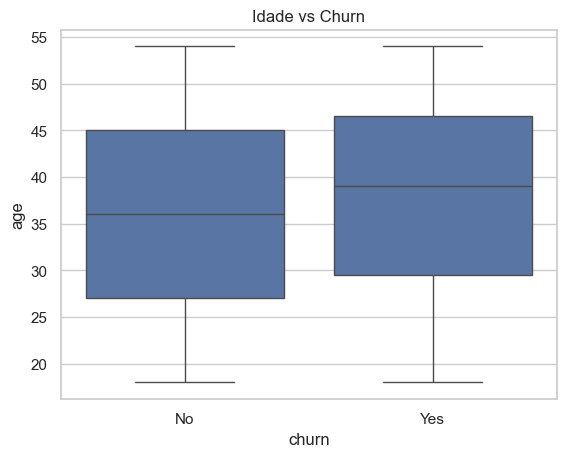

In [16]:
# Verificando a média de idade de quem sai vs quem fica
sns.boxplot(x='churn', y='age', data=df)
plt.title('Idade vs Churn')
plt.show()

C:\Users\rafae\AppData\Local\Temp\ipykernel_82616\3205500993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


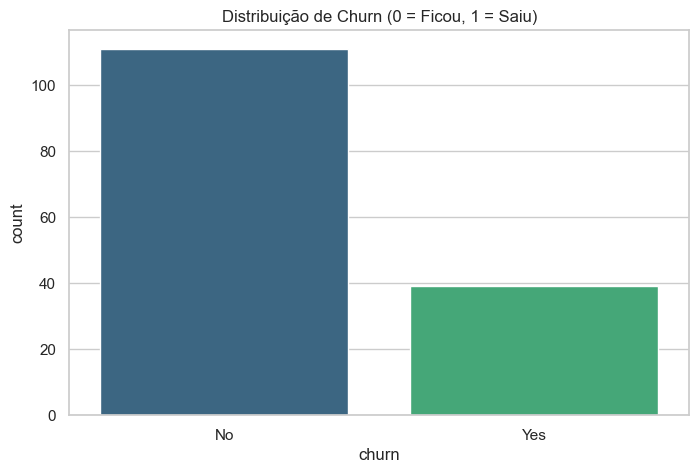

churn
No     74.0
Yes    26.0
Name: proportion, dtype: float64


In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribuição de Churn (0 = Ficou, 1 = Saiu)')
plt.show()

# Verificando em números (porcentagem)
print(df['churn'].value_counts(normalize=True) * 100)

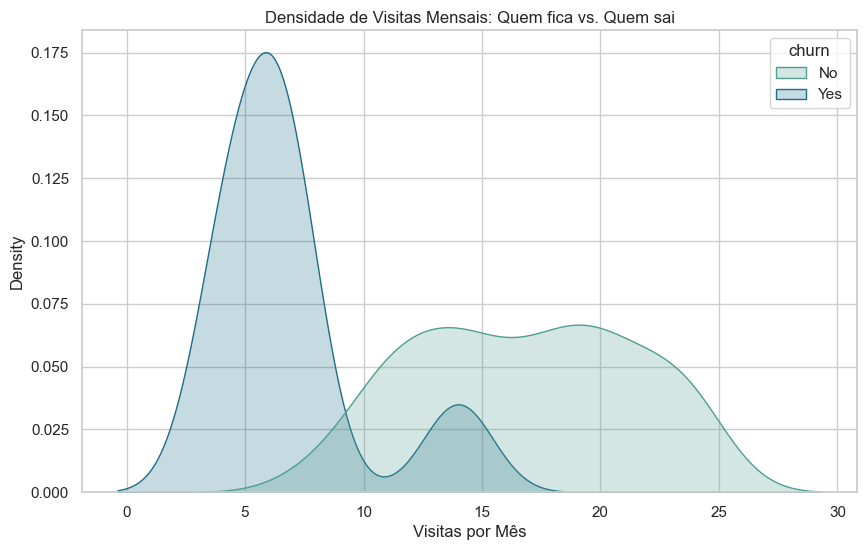

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='visits_per_month', hue='churn', fill=True, common_norm=False, palette='crest')
plt.title('Densidade de Visitas Mensais: Quem fica vs. Quem sai')
plt.xlabel('Visitas por Mês')
plt.show()

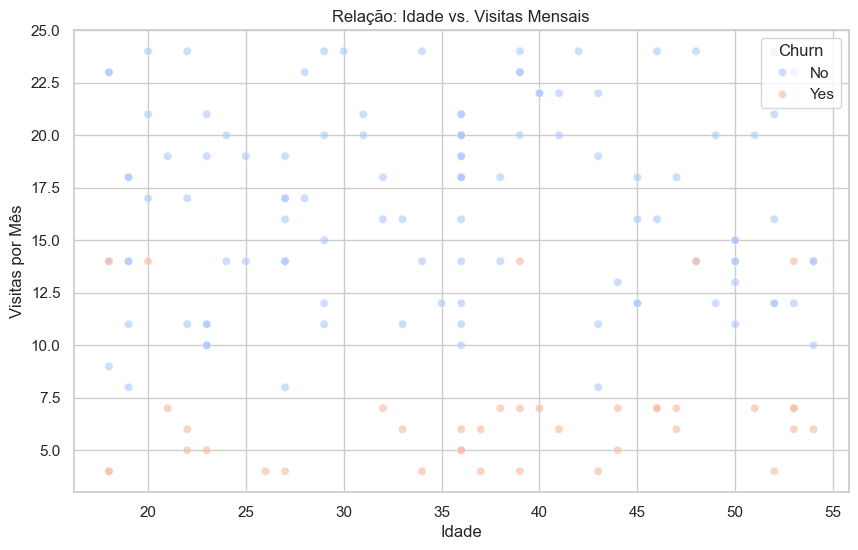

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='visits_per_month', hue='churn', alpha=0.6, palette='coolwarm')
plt.title('Relação: Idade vs. Visitas Mensais')
plt.xlabel('Idade')
plt.ylabel('Visitas por Mês')
plt.legend(title='Churn', loc='upper right')
plt.show()